# TF-IDF 기반 낚시성 기사 탐지 모델링 및 SHAP 해석

> **프로젝트**: AI Hub 낚시성 기사 탐지 데이터 기반 자동 탐지 모델 구축  
> **담당 파트**: TF-IDF 기반 모델링 및 SHAP 해석  
> **분석 목표**: 전처리된 뉴스 제목 데이터를 활용하여 낚시성 여부를 분류하고, 모델이 어떤 단어 특징을 근거로 판단했는지 해석한다.  
> **사용 데이터**: `work_pool_tfidf_tokens.parquet`  
> **주의 사항**: `test_final.parquet`은 최종 평가 전용 데이터이므로 본 분석 단계에서는 사용하지 않는다.

## 0. 분석 개요

본 노트북은 전처리 담당자가 생성한 `work_pool_tfidf_tokens.parquet` 파일을 기반으로 TF-IDF 모델링을 수행한다.  
분석은 크게 두 가지 분류 과제로 나누어 진행한다.

1. **이진 분류**  
   - 정상 기사와 낚시성 기사를 구분한다.
   - `binary_label`을 사용한다.
   - 0은 정상 기사, 1은 낚시성 기사이다.

2. **다중 분류**  
   - 낚시성 기사 중 Clickbait_Direct 데이터만 사용하여 6개 낚시성 유형을 분류한다.
   - `type_label`을 사용한다.
   - `type_label = -1`인 데이터는 유형 라벨이 없으므로 다중 분류에서 제외한다.

모델은 TF-IDF 벡터화를 적용한 뒤, Logistic Regression과 LinearSVC를 비교한다.  
이후 성능이 더 우수한 모델을 중심으로 SHAP 해석을 수행하여 모델 판단에 기여한 주요 단어 특징을 분석한다.

## 1. 라이브러리 및 데이터 로딩

분석에 필요한 기본 라이브러리를 불러오고, Google Drive에 저장된 전처리 완료 데이터 파일을 Colab 환경으로 복사한다.  
본 분석에서는 TF-IDF 트랙 전처리가 완료된 `work_pool_tfidf_tokens.parquet` 파일을 사용한다.

이 파일에는 뉴스 제목에 대한 형태소 분석, 불용어 제거, 특수부호 신호 추가 등이 반영되어 있으며, 모델 입력에는 최종 토큰 컬럼인 `title_tokens`를 사용한다.

In [ ]:
!git clone https://github.com/ysleecn1234/text-mining-2026.git

Cloning into 'text-mining-2026'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 37 (delta 7), reused 30 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 353.18 KiB | 8.41 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [ ]:
%cd text-mining-2026

/content/text-mining-2026


In [ ]:
!ls

bert_track.ipynb     modeling_guide.md		tfidf_track.ipynb
data		     preprocessing_pipeline.md	youngmin_guide.md
eda_work_pool.ipynb  progress_log.md
LICENSE		     README.md


In [ ]:
!pip install pandas pyarrow scikit-learn matplotlib seaborn

In [ ]:
!pip install shap

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls -lh "/content/drive/MyDrive/text-mining-2026/data/processed"

total 1.1G
-rw------- 1 root root 2.9K May 11 11:31 README.md
-rw------- 1 root root 116M May 11 11:31 test_final.parquet
-rw------- 1 root root 358M May 11 11:31 work_pool_clickbait_auto.parquet
-rw------- 1 root root 132M May 11 11:31 work_pool_clickbait_direct.parquet
-rw------- 1 root root 441M May 11 11:31 work_pool_nonclickbait_auto.parquet
-rw------- 1 root root  59M May 11 11:31 work_pool_tfidf_tokens.parquet


In [ ]:
!mkdir -p data/processed

!cp "/content/drive/MyDrive/text-mining-2026/data/processed/work_pool_tfidf_tokens.parquet" "data/processed/"

In [ ]:
!ls -lh data/processed

total 59M
-rw-r--r-- 1 root root 2.9K May 13 08:20 README.md
-rw------- 1 root root  59M May 13 08:22 work_pool_tfidf_tokens.parquet


## 2. TF-IDF 전처리 데이터 로딩

모델링에는 전처리 담당자가 생성한 `work_pool_tfidf_tokens.parquet` 파일을 사용한다.  
이 파일은 전체 work_pool 데이터 291,466건을 포함하며, TF-IDF 모델링을 위해 제목 텍스트가 형태소 분석과 불용어 제거 과정을 거친 상태이다.

주요 컬럼은 다음과 같다.

- `newsID`: 기사 ID
- `binary_label`: 이진 분류 라벨, 0=정상, 1=낚시성
- `type_label`: 낚시성 유형 라벨, 0~5=유형, -1=유형 없음
- `title_clean`: 정제된 제목
- `title_tfidf`: TF-IDF 전처리용 제목
- `title_morphs`: 형태소 분석 결과
- `title_tokens`: 최종 TF-IDF 입력 토큰

In [33]:
import pandas as pd

df_tfidf = pd.read_parquet('data/processed/work_pool_tfidf_tokens.parquet')

print("데이터 크기:", df_tfidf.shape)
print("컬럼:", df_tfidf.columns.tolist())
df_tfidf.head()

데이터 크기: (291466, 8)
컬럼: ['newsID', 'binary_label', 'type_label', 'source_class', 'title_clean', 'title_tfidf', 'title_morphs', 'title_tokens']


,newsID,binary_label,type_label,source_class,title_clean,title_tfidf,title_morphs,title_tokens
0,LC_M03_089986,1,-1,clickbait_auto,RM이 부산서 본 이 전시 ...볼탕스키 작품이 말하는 것들,RM이 부산서 본 이 전시 ...볼탕스키 작품이 말하는 것들,이 부산 보 전시 볼 탕 스키 작품 말,부산 전시 스키 작품 HAS_ELLIPSIS
1,GB_M11_057148,1,-1,clickbait_auto,"오미크론 250명 입원에도…英 당국 \""규제 계획 없어\""","오미크론 250명 입원에도…英 당국 \""규제 계획 없어\""",오미 크 <NUM> 입원 당국 규제 계획 없어,오미 입원 당국 규제 없어
2,PO_M08_105090,1,-1,clickbait_auto,"尹 '원전 안전성' 인터뷰 논란에 캠프 \""의미 다르게 전달됐다\""","尹 '원전 안전성' 인터뷰 논란에 캠프 \""의미 다르게 전달됐다\""",원전 안전 인터뷰 논란 캠프 의미 다르 전달,원전 안전 인터뷰 논란 캠프 의미 다르 전달
3,EC_M05_019442,1,-1,clickbait_auto,"삼성준법위, 노사갈등·ESG '실질적 변화'에 힘 싣는다","삼성준법위, 노사갈등·ESG '실질적 변화'에 힘 싣는다",삼성 준법 위 노사 갈등 실질 변화 힘 싣,삼성 준법 노사 갈등 실질 변화
4,EC_M04_016483,1,-1,clickbait_auto,"주택아파트 마련, 담보대출금리비교 활용해서 '알뜰하게'","주택아파트 마련, 담보대출금리비교 활용해서 '알뜰하게'",주택 아파트 마련 담보 대출 금리 비교 활용,주택 아파트 마련 담보 대출 금리 비교 활용


### 2-1. K-Fold 전 중복 제거

모델링 가이드에 따라 K-Fold 교차검증을 수행하기 전에 `title_clean` 기준으로 중복 제목을 제거한다.  
EDA 결과 동일 텍스트 중복이 일부 확인되었으며, 동일한 제목이 train과 validation에 동시에 포함될 경우 data leakage가 발생할 수 있다.

따라서 모델링에 사용하기 전 `title_clean` 기준 중복을 제거한 뒤, 이후 라벨 분포 확인, TF-IDF 벡터화, 모델 학습을 모두 중복 제거된 데이터 기준으로 진행한다.

In [34]:
# ============================================================
# K-Fold 전 중복 제거
# - 동일 제목이 train/validation에 동시에 들어가는 data leakage 방지
# - 모델링 가이드에 따라 title_clean 기준으로 중복 제거
# ============================================================

before = len(df_tfidf)

df_tfidf = df_tfidf.drop_duplicates(subset=['title_clean']).reset_index(drop=True)

after = len(df_tfidf)

print(f"중복 제거 전: {before:,}건")
print(f"중복 제거 후: {after:,}건")
print(f"제거된 중복 수: {before - after:,}건")

중복 제거 전: 291,466건
중복 제거 후: 290,474건
제거된 중복 수: 992건


### 해석

데이터 로딩 결과, 중복 제거 전 기준 총 291,466건의 기사 데이터와 8개의 컬럼이 확인되었다. 이후 K-Fold 교차검증에서 동일 제목이 train/validation에 동시에 포함되는 data leakage를 방지하기 위해 `title_clean` 기준 중복을 제거하였다. 중복 제거 후 모델링에 사용된 데이터는 290,474건이다.

## 3. 라벨 분포 확인

모델링에 앞서 이진 분류와 다중 분류의 라벨 분포를 확인한다.  
라벨 분포를 확인하는 이유는 클래스 불균형 여부에 따라 모델 학습 방식이 달라질 수 있기 때문이다.

이진 분류에서는 정상 기사와 낚시성 기사의 비율을 확인하고, 다중 분류에서는 6개 낚시성 유형 간 데이터 수 차이를 확인한다.

In [35]:
print("이진 분류 라벨 분포")
print(df_tfidf['binary_label'].value_counts().sort_index())

print("\n다중 분류 라벨 분포")
print(df_tfidf['type_label'].value_counts().sort_index())

이진 분류 라벨 분포
binary_label
0    144658
1    145816
Name: count, dtype: int64

다중 분류 라벨 분포
type_label
-1    250368
 0     14863
 1     11685
 2      3554
 3      3696
 4      4228
 5      2080
Name: count, dtype: int64


### 해석

이진 분류 데이터는 정상 기사 144,658건, 낚시성 기사 145,816건으로 거의 1:1에 가까운 균형을 보였다.  
따라서 이진 분류에서는 별도의 `class_weight` 조정 없이 모델을 학습하였다.

다중 분류에서는 `type_label = -1`인 데이터가 250,368건으로 가장 많았다.  
이는 낚시성 유형 라벨이 없는 데이터이므로 다중 분류에서는 제외해야 한다.

실제 다중 분류에 사용되는 데이터는 `type_label`이 0~5인 Clickbait_Direct 데이터 40,106건이다.  
유형별 데이터 수는 최대 14,863건에서 최소 2,080건까지 차이가 나므로, 다중 분류 모델에서는 클래스 불균형을 고려해 `class_weight='balanced'`를 적용한다.

## 4. TF-IDF 벡터화

TF-IDF는 문서 내 단어의 중요도를 수치화하는 방식이다.  
본 분석에서는 전처리된 제목 토큰인 `title_tokens`를 입력으로 사용하여 각 뉴스 제목을 숫자 벡터로 변환한다.

`TfidfVectorizer`의 주요 설정은 다음과 같다.

- `max_features=10000`: 최대 10,000개의 단어 특징 사용
- `min_df=5`: 전체 문서에서 최소 5번 이상 등장한 단어만 사용
- `max_df=0.95`: 전체 문서의 95% 이상에서 등장하는 너무 일반적인 단어는 제외

이 과정을 통해 각 뉴스 제목은 머신러닝 모델이 학습할 수 있는 희소 행렬 형태로 변환된다.

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
import time

# 모델 입력: 전처리된 제목 토큰
corpus = df_tfidf['title_tokens'].fillna('').tolist()

print("TF-IDF 벡터화 시작...")
t = time.time()

vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.95
)

X = vectorizer.fit_transform(corpus)

print(f"완료! ({time.time()-t:.1f}초)")
print("X shape:", X.shape)
print("어휘 수:", len(vectorizer.vocabulary_))

TF-IDF 벡터화 시작...
완료! (4.1초)
X shape: (290474, 10000)
어휘 수: 10000


### 해석

TF-IDF 벡터화 결과, 중복 제거 후 290,474개의 기사 제목이 10,000개의 단어 특징으로 변환되었다.
즉, 모델은 제목 문장 자체를 직접 읽는 것이 아니라, 제목에 포함된 단어들의 TF-IDF 가중치를 기반으로 낚시성 여부를 판단하게 된다.

## 5. 이진 분류 모델링

이진 분류의 목표는 뉴스 제목이 정상 기사인지 낚시성 기사인지 구분하는 것이다.  
정답 라벨은 `binary_label`을 사용하며, 0은 정상 기사, 1은 낚시성 기사를 의미한다.

모델 성능 평가는 `StratifiedKFold`를 사용한 5-Fold 교차검증으로 진행한다.  
이 방식은 각 Fold에서 정상/낚시성 비율이 유지되도록 데이터를 나누기 때문에, 안정적인 성능 비교가 가능하다.

본 분석에서는 TF-IDF 기반 전통 머신러닝 모델로 Logistic Regression과 LinearSVC를 비교한다.

### 5-1. Logistic Regression 이진 분류

첫 번째 모델로 Logistic Regression을 사용한다.  
Logistic Regression은 선형 분류 모델로, 각 단어 특징이 낚시성 판단에 얼마나 기여하는지 계수 형태로 확인할 수 있다는 장점이 있다.  
따라서 이후 SHAP 및 계수 기반 해석에도 적합하다.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import time

# 정답 라벨: 0=정상, 1=낚시성
y_binary = df_tfidf['binary_label'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

binary_lr_results = []

print("TF-IDF + Logistic Regression 이진 분류 5-Fold 시작")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_binary), 1):
    print(f"\n[Fold {fold}] 학습 시작...")
    t = time.time()

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_binary[train_idx], y_binary[val_idx]

    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    prec = precision_score(y_val, pred, average='macro')
    rec = recall_score(y_val, pred, average='macro')
    f1 = f1_score(y_val, pred, average='macro')

    binary_lr_results.append({
        "model": "TF-IDF + Logistic Regression",
        "task": "binary",
        "fold": fold,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "time_sec": time.time() - t
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision(macro): {prec:.4f}")
    print(f"Recall(macro): {rec:.4f}")
    print(f"F1(macro): {f1:.4f}")
    print(f"소요 시간: {time.time()-t:.1f}초")

binary_lr_df = pd.DataFrame(binary_lr_results)

print("\n" + "=" * 60)
print("5-Fold 평균 성능")
print("=" * 60)
display(binary_lr_df)

summary = binary_lr_df[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']].agg(['mean', 'std'])
display(summary)

TF-IDF + Logistic Regression 이진 분류 5-Fold 시작

[Fold 1] 학습 시작...
Accuracy: 0.6338
Precision(macro): 0.6348
Recall(macro): 0.6339
F1(macro): 0.6332
소요 시간: 3.2초

[Fold 2] 학습 시작...
Accuracy: 0.6316
Precision(macro): 0.6329
Recall(macro): 0.6317
F1(macro): 0.6308
소요 시간: 3.4초

[Fold 3] 학습 시작...
Accuracy: 0.6351
Precision(macro): 0.6361
Recall(macro): 0.6353
F1(macro): 0.6347
소요 시간: 3.0초

[Fold 4] 학습 시작...
Accuracy: 0.6318
Precision(macro): 0.6331
Recall(macro): 0.6320
F1(macro): 0.6311
소요 시간: 2.4초

[Fold 5] 학습 시작...
Accuracy: 0.6319
Precision(macro): 0.6333
Recall(macro): 0.6320
F1(macro): 0.6311
소요 시간: 2.3초

5-Fold 평균 성능


,model,task,fold,accuracy,precision_macro,recall_macro,f1_macro,time_sec
0,TF-IDF + Logistic Regression,binary,1,0.633772,0.634850,0.633939,0.633211,3.227480
1,TF-IDF + Logistic Regression,binary,2,0.631552,0.632950,0.631743,0.630781,3.403340
2,TF-IDF + Logistic Regression,binary,3,0.635149,0.636093,0.635303,0.634672,3.003390
3,TF-IDF + Logistic Regression,binary,4,0.631776,0.633102,0.631962,0.631051,2.426284
4,TF-IDF + Logistic Regression,binary,5,0.631855,0.633276,0.632049,0.631074,2.305455


,accuracy,precision_macro,recall_macro,f1_macro
mean,0.632821,0.634054,0.632999,0.632158
std,0.001578,0.001372,0.001561,0.001712


### 해석

TF-IDF + Logistic Regression 이진 분류 모델의 5-Fold 평균 Accuracy는 0.6328, Macro F1-score는 0.6321로 나타났다.  
이는 단어 빈도 기반의 TF-IDF 특징만으로도 정상 기사와 낚시성 기사를 어느 정도 구분할 수 있음을 보여준다.

다만 성능이 매우 높은 수준은 아니므로, TF-IDF 기반 모델은 낚시성 기사 제목의 표면적 표현 특징을 포착하는 데에는 유용하지만, 제목과 본문의 의미적 불일치나 문맥 정보까지 충분히 반영하는 데에는 한계가 있다고 볼 수 있다.

### 5-2. LinearSVC 이진 분류

두 번째 모델로 LinearSVC를 사용한다.  
LinearSVC는 텍스트 분류에서 자주 사용되는 선형 SVM 계열 모델로, TF-IDF와 함께 사용할 때 비교적 좋은 성능을 보이는 경우가 많다.

Logistic Regression과 비교하여 TF-IDF 기반 이진 분류에서 어떤 모델이 더 적합한지 확인한다.

In [38]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import time

y_binary = df_tfidf['binary_label'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

binary_svm_results = []

print("TF-IDF + LinearSVC 이진 분류 5-Fold 시작")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_binary), 1):
    print(f"\n[Fold {fold}] 학습 시작...")
    t = time.time()

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_binary[train_idx], y_binary[val_idx]

    model = LinearSVC(
        random_state=42,
        max_iter=5000
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    prec = precision_score(y_val, pred, average='macro')
    rec = recall_score(y_val, pred, average='macro')
    f1 = f1_score(y_val, pred, average='macro')

    binary_svm_results.append({
        "model": "TF-IDF + LinearSVC",
        "task": "binary",
        "fold": fold,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "time_sec": time.time() - t
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision(macro): {prec:.4f}")
    print(f"Recall(macro): {rec:.4f}")
    print(f"F1(macro): {f1:.4f}")
    print(f"소요 시간: {time.time()-t:.1f}초")

binary_svm_df = pd.DataFrame(binary_svm_results)

print("\n" + "=" * 60)
print("5-Fold 평균 성능")
print("=" * 60)
display(binary_svm_df)

svm_summary = binary_svm_df[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']].agg(['mean', 'std'])
display(svm_summary)

TF-IDF + LinearSVC 이진 분류 5-Fold 시작

[Fold 1] 학습 시작...
Accuracy: 0.6307
Precision(macro): 0.6314
Recall(macro): 0.6308
F1(macro): 0.6303
소요 시간: 2.4초

[Fold 2] 학습 시작...
Accuracy: 0.6290
Precision(macro): 0.6300
Recall(macro): 0.6292
F1(macro): 0.6285
소요 시간: 4.2초

[Fold 3] 학습 시작...
Accuracy: 0.6303
Precision(macro): 0.6308
Recall(macro): 0.6304
F1(macro): 0.6300
소요 시간: 1.9초

[Fold 4] 학습 시작...
Accuracy: 0.6284
Precision(macro): 0.6292
Recall(macro): 0.6285
F1(macro): 0.6279
소요 시간: 1.7초

[Fold 5] 학습 시작...
Accuracy: 0.6283
Precision(macro): 0.6292
Recall(macro): 0.6284
F1(macro): 0.6278
소요 시간: 1.8초

5-Fold 평균 성능


,model,task,fold,accuracy,precision_macro,recall_macro,f1_macro,time_sec
0,TF-IDF + LinearSVC,binary,1,0.630657,0.631351,0.630790,0.630307,2.443932
1,TF-IDF + LinearSVC,binary,2,0.629039,0.629981,0.629195,0.628532,4.181416
2,TF-IDF + LinearSVC,binary,3,0.630295,0.630820,0.630409,0.630043,1.930978
3,TF-IDF + LinearSVC,binary,4,0.628367,0.629223,0.628517,0.627911,1.725894
4,TF-IDF + LinearSVC,binary,5,0.628275,0.629219,0.628433,0.627764,1.795785


,accuracy,precision_macro,recall_macro,f1_macro
mean,0.629327,0.630119,0.629469,0.628911
std,0.001097,0.000954,0.001082,0.001193


### 해석

TF-IDF + LinearSVC 이진 분류 모델의 5-Fold 평균 Accuracy는 0.6293, Macro F1-score는 0.6289로 나타났다.  
Logistic Regression과 비교하면 성능 차이는 크지 않았지만, 주요 지표에서 Logistic Regression이 근소하게 더 높은 성능을 보였다.

### 5-3. 이진 분류 결과 비교

| 모델 | Accuracy 평균 | Precision Macro | Recall Macro | F1 Macro |
|---|---:|---:|---:|---:|
| TF-IDF + Logistic Regression | 0.6328 | 0.6341 | 0.6330 | 0.6322 |
| TF-IDF + LinearSVC | 0.6293 | 0.6301 | 0.6295 | 0.6289 |

이진 분류에서는 Logistic Regression과 LinearSVC 모두 비슷한 수준의 성능을 보였다.  
그러나 평균 Accuracy, Precision, Recall, Macro F1-score 모두에서 Logistic Regression이 LinearSVC보다 근소하게 높은 값을 기록하였다.

따라서 TF-IDF 기반 이진 분류에서는 Logistic Regression을 대표 모델로 선정하였다.

## 6. 다중 분류 모델링

다중 분류의 목표는 낚시성 기사 중 Clickbait_Direct 데이터에 대해 6개 낚시성 유형을 분류하는 것이다.  
다중 분류에서는 `type_label`을 사용하며, `type_label = -1`인 데이터는 유형 라벨이 없기 때문에 제외한다.

유형 라벨은 다음과 같다.

| type_label | 유형 |
|---|---|
| 0 | 의문유발-부호 |
| 1 | 의문유발-은닉 |
| 2 | 선정표현 |
| 3 | 속어/줄임말 |
| 4 | 사실과대 |
| 5 | 주어왜곡 |

### 6-1. 다중 분류 데이터 필터링

다중 분류는 낚시성 유형 라벨이 존재하는 Clickbait_Direct 데이터만을 대상으로 수행한다.  
따라서 `type_label != -1` 조건을 적용하여 6개 유형 라벨이 존재하는 데이터만 추출한다.

In [39]:
# 다중 분류용 데이터만 필터링
df_multi = df_tfidf[df_tfidf['type_label'] != -1].copy()

print("다중 분류 데이터 크기:", df_multi.shape)
print(df_multi['type_label'].value_counts().sort_index())

다중 분류 데이터 크기: (40106, 8)
type_label
0    14863
1    11685
2     3554
3     3696
4     4228
5     2080
Name: count, dtype: int64


### 해석

다중 분류 대상 데이터는 총 40,106건으로 확인되었다.  
유형별 데이터 수는 의문유발-부호와 의문유발-은닉 유형에 많이 분포되어 있으며, 주어왜곡 유형은 상대적으로 적게 나타났다.

따라서 다중 분류 모델 학습 시 클래스 불균형을 고려할 필요가 있다.

### 6-2. 다중 분류용 TF-IDF 벡터화

다중 분류는 이진 분류와 달리 Clickbait_Direct 데이터만 사용하므로, 필터링된 데이터에 대해 TF-IDF 벡터를 새로 생성한다.  
이때 모델 입력은 동일하게 `title_tokens` 컬럼을 사용한다.

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
import time

corpus_multi = df_multi['title_tokens'].fillna('').tolist()
y_multi = df_multi['type_label'].values

print("다중 분류 TF-IDF 벡터화 시작...")
t = time.time()

vectorizer_multi = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.95
)

X_multi = vectorizer_multi.fit_transform(corpus_multi)

print(f"완료! ({time.time()-t:.1f}초)")
print("X_multi shape:", X_multi.shape)
print("어휘 수:", len(vectorizer_multi.vocabulary_))

다중 분류 TF-IDF 벡터화 시작...
완료! (0.8초)
X_multi shape: (40106, 7565)
어휘 수: 7565


### 해석

다중 분류용 TF-IDF 벡터화 결과, 유형 라벨이 존재하는 Clickbait_Direct 기사 제목 40,106개가 7,565개의 단어 특징으로 변환되었다. 이진 분류보다 사용 데이터가 적기 때문에 최종 어휘 수 역시 10,000개보다 적게 형성되었다.

### 6-3. Logistic Regression 다중 분류

다중 분류에서도 Logistic Regression을 먼저 적용한다.  
다만 유형별 데이터 수 차이가 크기 때문에 `class_weight='balanced'`를 적용하여 소수 클래스가 학습에서 과도하게 무시되지 않도록 한다.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import time

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

multi_lr_results = []

print("TF-IDF + Logistic Regression 다중 분류 5-Fold 시작")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_multi, y_multi), 1):
    print(f"\n[Fold {fold}] 학습 시작...")
    t = time.time()

    X_train, X_val = X_multi[train_idx], X_multi[val_idx]
    y_train, y_val = y_multi[train_idx], y_multi[val_idx]

    model = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    prec = precision_score(y_val, pred, average='macro', zero_division=0)
    rec = recall_score(y_val, pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, pred, average='macro', zero_division=0)

    multi_lr_results.append({
        "model": "TF-IDF + Logistic Regression",
        "task": "multi",
        "fold": fold,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "time_sec": time.time() - t
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision(macro): {prec:.4f}")
    print(f"Recall(macro): {rec:.4f}")
    print(f"F1(macro): {f1:.4f}")
    print(f"소요 시간: {time.time()-t:.1f}초")

multi_lr_df = pd.DataFrame(multi_lr_results)

print("\n" + "=" * 60)
print("5-Fold 평균 성능")
print("=" * 60)
display(multi_lr_df)

multi_lr_summary = multi_lr_df[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']].agg(['mean', 'std'])
display(multi_lr_summary)

TF-IDF + Logistic Regression 다중 분류 5-Fold 시작

[Fold 1] 학습 시작...
Accuracy: 0.5802
Precision(macro): 0.4726
Recall(macro): 0.4895
F1(macro): 0.4664
소요 시간: 3.0초

[Fold 2] 학습 시작...
Accuracy: 0.5787
Precision(macro): 0.4719
Recall(macro): 0.4945
F1(macro): 0.4714
소요 시간: 3.4초

[Fold 3] 학습 시작...
Accuracy: 0.5726
Precision(macro): 0.4628
Recall(macro): 0.4791
F1(macro): 0.4574
소요 시간: 4.8초

[Fold 4] 학습 시작...
Accuracy: 0.5777
Precision(macro): 0.4739
Recall(macro): 0.4922
F1(macro): 0.4698
소요 시간: 2.8초

[Fold 5] 학습 시작...
Accuracy: 0.5669
Precision(macro): 0.4543
Recall(macro): 0.4717
F1(macro): 0.4491
소요 시간: 2.0초

5-Fold 평균 성능


,model,task,fold,accuracy,precision_macro,recall_macro,f1_macro,time_sec
0,TF-IDF + Logistic Regression,multi,1,0.580155,0.472576,0.489460,0.466385,2.989266
1,TF-IDF + Logistic Regression,multi,2,0.578731,0.471880,0.494514,0.471379,3.401313
2,TF-IDF + Logistic Regression,multi,3,0.572622,0.462790,0.479135,0.457439,4.772856
3,TF-IDF + Logistic Regression,multi,4,0.577733,0.473891,0.492200,0.469847,2.813634
4,TF-IDF + Logistic Regression,multi,5,0.566887,0.454263,0.471671,0.449067,2.042445


,accuracy,precision_macro,recall_macro,f1_macro
mean,0.575226,0.467080,0.485396,0.462823
std,0.005459,0.008401,0.009663,0.009400


### 해석

TF-IDF + Logistic Regression 다중 분류 모델의 5-Fold 평균 Accuracy는 0.5752, Macro F1-score는 0.4628로 나타났다.  
이진 분류에 비해 성능이 낮아졌는데, 이는 6개 유형을 구분해야 하는 문제 자체가 더 어렵고, 유형 간 데이터 불균형도 존재하기 때문이다.

특히 주어왜곡처럼 문맥적 판단이 필요한 유형은 단순 단어 빈도 기반 TF-IDF 모델만으로는 구분에 한계가 있을 수 있다.

### 6-4. LinearSVC 다중 분류

Logistic Regression과 비교하기 위해 LinearSVC도 다중 분류에 적용한다.  
마찬가지로 클래스 불균형을 고려하여 `class_weight='balanced'`를 사용한다.

In [42]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import time

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

multi_svm_results = []

print("TF-IDF + LinearSVC 다중 분류 5-Fold 시작")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_multi, y_multi), 1):
    print(f"\n[Fold {fold}] 학습 시작...")
    t = time.time()

    X_train, X_val = X_multi[train_idx], X_multi[val_idx]
    y_train, y_val = y_multi[train_idx], y_multi[val_idx]

    model = LinearSVC(
        class_weight='balanced',
        random_state=42,
        max_iter=5000
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    acc = accuracy_score(y_val, pred)
    prec = precision_score(y_val, pred, average='macro', zero_division=0)
    rec = recall_score(y_val, pred, average='macro', zero_division=0)
    f1 = f1_score(y_val, pred, average='macro', zero_division=0)

    multi_svm_results.append({
        "model": "TF-IDF + LinearSVC",
        "task": "multi",
        "fold": fold,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "time_sec": time.time() - t
    })

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision(macro): {prec:.4f}")
    print(f"Recall(macro): {rec:.4f}")
    print(f"F1(macro): {f1:.4f}")
    print(f"소요 시간: {time.time()-t:.1f}초")

multi_svm_df = pd.DataFrame(multi_svm_results)

print("\n" + "=" * 60)
print("5-Fold 평균 성능")
print("=" * 60)
display(multi_svm_df)

multi_svm_summary = multi_svm_df[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']].agg(['mean', 'std'])
display(multi_svm_summary)

TF-IDF + LinearSVC 다중 분류 5-Fold 시작

[Fold 1] 학습 시작...
Accuracy: 0.5723
Precision(macro): 0.4506
Recall(macro): 0.4625
F1(macro): 0.4530
소요 시간: 0.7초

[Fold 2] 학습 시작...
Accuracy: 0.5809
Precision(macro): 0.4587
Recall(macro): 0.4703
F1(macro): 0.4617
소요 시간: 0.7초

[Fold 3] 학습 시작...
Accuracy: 0.5721
Precision(macro): 0.4470
Recall(macro): 0.4573
F1(macro): 0.4485
소요 시간: 0.7초

[Fold 4] 학습 시작...
Accuracy: 0.5680
Precision(macro): 0.4460
Recall(macro): 0.4550
F1(macro): 0.4472
소요 시간: 0.7초

[Fold 5] 학습 시작...
Accuracy: 0.5670
Precision(macro): 0.4442
Recall(macro): 0.4555
F1(macro): 0.4462
소요 시간: 0.7초

5-Fold 평균 성능


,model,task,fold,accuracy,precision_macro,recall_macro,f1_macro,time_sec
0,TF-IDF + LinearSVC,multi,1,0.572301,0.450638,0.462527,0.453016,0.730370
1,TF-IDF + LinearSVC,multi,2,0.580850,0.458744,0.470284,0.461734,0.727199
2,TF-IDF + LinearSVC,multi,3,0.572123,0.447010,0.457288,0.448523,0.745589
3,TF-IDF + LinearSVC,multi,4,0.568009,0.446008,0.454975,0.447207,0.713942
4,TF-IDF + LinearSVC,multi,5,0.567012,0.444185,0.455511,0.446190,0.723871


,accuracy,precision_macro,recall_macro,f1_macro
mean,0.572059,0.449317,0.460117,0.451334
std,0.005460,0.005771,0.006420,0.006372


### 해석

TF-IDF + LinearSVC 다중 분류 모델의 5-Fold 평균 Accuracy는 0.5721, Macro F1-score는 0.4513으로 나타났다.  
Logistic Regression과 비교하면 Accuracy와 Macro F1-score 모두에서 Logistic Regression이 더 높은 성능을 보였다.

### 6-5. 다중 분류 결과 비교

| 모델 | Accuracy 평균 | Precision Macro | Recall Macro | F1 Macro |
|---|---:|---:|---:|---:|
| TF-IDF + Logistic Regression | 0.5752 | 0.4671 | 0.4854 | 0.4628 |
| TF-IDF + LinearSVC | 0.5721 | 0.4493 | 0.4601 | 0.4513 |

다중 분류에서도 Logistic Regression이 LinearSVC보다 전반적으로 높은 성능을 보였다.  
따라서 TF-IDF 기반 다중 분류에서도 Logistic Regression이 상대적으로 안정적인 모델로 판단된다.

다만 다중 분류 성능은 이진 분류보다 낮게 나타났다.  
이는 6개 낚시성 유형 간 데이터 불균형이 존재하고, 일부 유형은 제목의 단어만으로 구분하기 어렵기 때문으로 해석할 수 있다.

## 7. 최종 TF-IDF 대표 모델 선정

이진 분류와 다중 분류 모두에서 Logistic Regression이 LinearSVC보다 근소하게 높은 성능을 보였다.  
따라서 본 TF-IDF 트랙에서는 Logistic Regression을 대표 모델로 선정하였다.

이후 해석 단계에서는 전체 work_pool 데이터를 기반으로 학습한 TF-IDF + Logistic Regression 이진 분류 모델을 사용하여 SHAP 해석을 수행한다.  
이진 분류 모델을 중심으로 해석하는 이유는 본 프로젝트의 핵심 목표가 우선적으로 정상 기사와 낚시성 기사를 구분하는 것이기 때문이다.

## 8. SHAP 해석

SHAP는 모델이 특정 예측을 할 때 각 특징이 예측에 얼마나 기여했는지를 설명하는 해석 기법이다.  
본 분석에서는 TF-IDF + Logistic Regression 모델이 어떤 단어 특징을 근거로 낚시성 여부를 판단했는지 확인하기 위해 SHAP를 적용한다.

SHAP 해석을 통해 단순히 모델 성능을 제시하는 것에서 나아가, 모델이 실제로 낚시성 기사 제목의 어떤 표현적 특징을 학습했는지 설명할 수 있다.

### 8-1. SHAP 해석용 최종 모델 학습

5-Fold 교차검증은 모델 성능을 평가하기 위한 과정이다.  
SHAP 해석에서는 최종적으로 선택한 Logistic Regression 모델을 전체 work_pool 데이터에 다시 학습시킨 뒤, 해당 모델을 대상으로 해석을 수행한다.

이 과정에서 `test_final.parquet`은 사용하지 않는다.

In [43]:
from sklearn.linear_model import LogisticRegression
import time

# 이진 분류 라벨
y_binary = df_tfidf['binary_label'].values

print("SHAP 해석용 Logistic Regression 최종 모델 학습 시작...")
t = time.time()

lr_binary_final = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_binary_final.fit(X, y_binary)

print(f"학습 완료! ({time.time()-t:.1f}초)")

SHAP 해석용 Logistic Regression 최종 모델 학습 시작...
학습 완료! (3.1초)


### 해석

전체 work_pool 데이터를 사용하여 SHAP 해석용 Logistic Regression 최종 모델을 학습하였다.  
이 모델은 이후 SHAP 값 계산과 단어별 계수 분석에 사용된다.

### 8-2. SHAP 샘플링 및 SHAP 값 계산

중복 제거 후 모델링에 사용된 work_pool 데이터는 290,474건이며, TF-IDF 특징 수는 10,000개이다.  
전체 데이터에 대해 SHAP 값을 모두 계산하고 시각화하면 계산량과 메모리 사용량이 매우 커질 수 있다.

따라서 본 분석에서는 모델은 전체 데이터로 학습하되, SHAP 시각화에는 정상 기사 2,500건과 낚시성 기사 2,500건을 추출한 총 5,000건의 균형 샘플을 사용한다.  
이는 정상/낚시성 비율이 한쪽으로 치우치지 않도록 하기 위한 설정이다.

In [44]:
import numpy as np
import shap
import time

# 0=정상, 1=낚시성 라벨
y_binary = df_tfidf['binary_label'].values

# 정상/낚시성 인덱스 분리
normal_idx = np.where(y_binary == 0)[0]
clickbait_idx = np.where(y_binary == 1)[0]

# 재현 가능하도록 seed 고정
np.random.seed(42)

# 각 클래스에서 2,500건씩 샘플링
sample_normal = np.random.choice(normal_idx, size=2500, replace=False)
sample_clickbait = np.random.choice(clickbait_idx, size=2500, replace=False)

# 두 샘플을 합쳐 총 5,000건 구성
sample_idx = np.concatenate([sample_normal, sample_clickbait])
np.random.shuffle(sample_idx)

# SHAP 계산용 샘플 데이터
X_sample = X[sample_idx]
y_sample = y_binary[sample_idx]

print("SHAP 샘플 크기:", X_sample.shape)
print("샘플 라벨 분포")
print("  정상(0):", np.sum(y_sample == 0))
print("  낚시성(1):", np.sum(y_sample == 1))

# SHAP LinearExplainer 생성
# Logistic Regression 같은 선형 모델에는 LinearExplainer가 적합함
print("\nSHAP Explainer 생성 중...")
t = time.time()

explainer = shap.LinearExplainer(
    lr_binary_final,
    X_sample
)

print(f"Explainer 생성 완료! ({time.time() - t:.1f}초)")

# SHAP 값 계산
print("\nSHAP 값 계산 중...")
t = time.time()

shap_values = explainer.shap_values(X_sample)

print(f"SHAP 값 계산 완료! ({time.time() - t:.1f}초)")

# 결과 형태 확인
print("\nSHAP 결과 확인")
print("X_sample shape:", X_sample.shape)

if isinstance(shap_values, list):
    print("shap_values type: list")
    print("shap_values[0] shape:", shap_values[0].shape)
else:
    print("shap_values shape:", shap_values.shape)

SHAP 샘플 크기: (5000, 10000)
샘플 라벨 분포
  정상(0): 2500
  낚시성(1): 2500

SHAP Explainer 생성 중...
Explainer 생성 완료! (0.0초)

SHAP 값 계산 중...
SHAP 값 계산 완료! (1.3초)

SHAP 결과 확인
X_sample shape: (5000, 10000)
shap_values shape: (5000, 10000)


### 해석

SHAP 값 계산 결과, 5,000개의 샘플과 10,000개의 TF-IDF 특징에 대해 SHAP 값이 계산되었다.  
이는 각 기사 제목에서 각 단어 특징이 낚시성 판단에 얼마나 기여했는지를 나타낸다.

### 8-3. SHAP 시각화를 위한 한글 폰트 설정

SHAP Summary Plot에는 한국어 단어가 표시되므로, Colab 기본 폰트인 DejaVu Sans를 사용할 경우 한글이 깨질 수 있다.  
따라서 NanumGothic 폰트를 설치하고 matplotlib에 직접 등록하여 그래프의 한글 단어가 정상적으로 표시되도록 설정한다.

In [45]:
# ============================================================
# 한글 폰트 설정: Colab + matplotlib + SHAP용
# ============================================================

!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import os

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

print("폰트 파일 존재 여부:", os.path.exists(font_path))

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print("등록된 폰트 이름:", font_name)

mpl.rcParams["font.family"] = font_name
mpl.rcParams["font.sans-serif"] = [font_name]
mpl.rcParams["axes.unicode_minus"] = False

print("현재 matplotlib font.family:", mpl.rcParams["font.family"])

폰트 파일 존재 여부: True
등록된 폰트 이름: NanumGothic
현재 matplotlib font.family: ['NanumGothic']


### 8-4. SHAP Summary Plot 시각화

SHAP Summary Plot은 모델 판단에 영향을 많이 준 상위 단어 특징을 시각화한다.  
그래프의 y축은 주요 단어 특징을 나타내며, 위에 위치할수록 전체 모델 판단에 큰 영향을 준 특징이다.  
x축의 SHAP value가 양수 방향이면 낚시성 기사 판단에 기여한 것이고, 음수 방향이면 정상 기사 판단에 기여한 것으로 해석할 수 있다.

/tmp/ipykernel_6413/3706576640.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


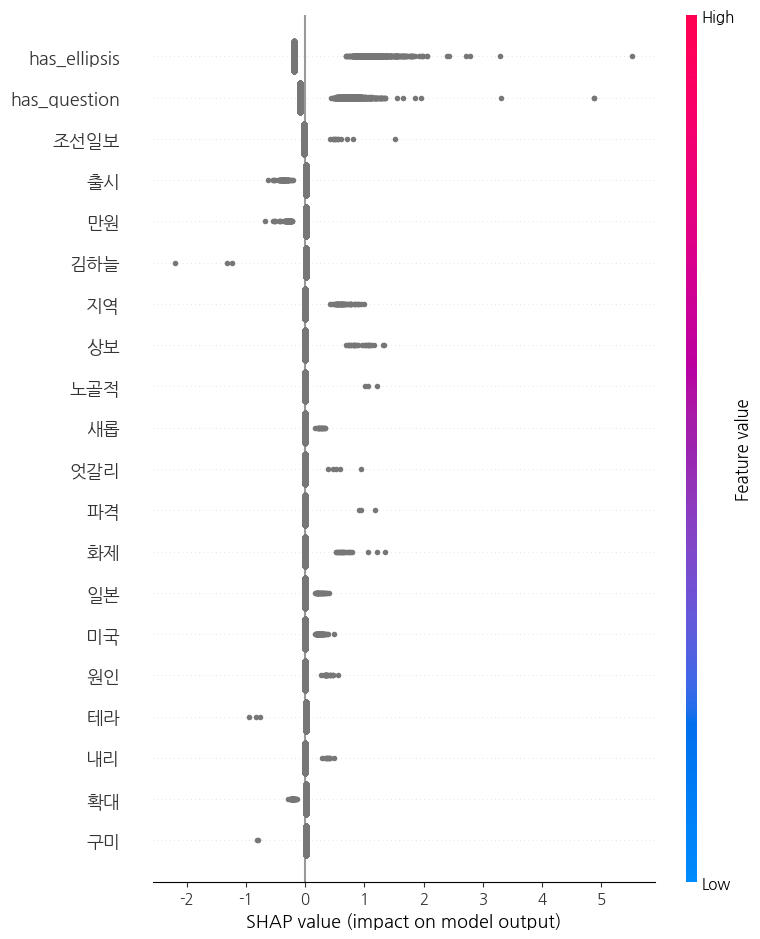

In [46]:
import matplotlib.pyplot as plt

# TF-IDF 단어 목록
feature_names = vectorizer.get_feature_names_out()

# SHAP summary plot
# max_display=20: 영향력이 큰 상위 20개 단어만 표시
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=True
)

### 해석

SHAP Summary Plot 분석 결과, TF-IDF + Logistic Regression 모델에서 낚시성 판단에 가장 크게 기여한 특징은 `has_ellipsis`와 `has_question`으로 나타났다.  
`has_ellipsis`는 제목에 말줄임표가 포함되어 있는지를 나타내며, `has_question`은 제목에 물음표가 포함되어 있는지를 나타낸다.

두 특징 모두 양의 SHAP value 방향으로 강하게 나타났기 때문에, 말줄임표나 물음표가 포함된 제목은 모델이 낚시성 기사로 판단하는 데 중요한 영향을 주었다고 해석할 수 있다.  
이는 낚시성 기사 제목이 정보를 일부 숨기거나 독자의 궁금증을 유발하는 방식으로 클릭을 유도한다는 특징과 연결된다.

반면 일부 지역명, 기관명, 주제어도 상위 특징으로 나타났는데, 이는 TF-IDF 모델이 문맥 의미보다는 데이터셋 내 단어 출현 패턴에 민감하게 반응한다는 한계를 보여준다.

### 8-5. Logistic Regression 계수 기반 주요 단어 분석

Logistic Regression의 계수를 확인하면 각 단어 특징이 낚시성 또는 정상 판단에 어느 방향으로 기여했는지 확인할 수 있다.

- 계수가 양수이면 낚시성 기사 판단에 기여한다.
- 계수가 음수이면 정상 기사 판단에 기여한다.
- 계수의 절댓값이 클수록 모델 판단에 미치는 영향이 크다.

이를 통해 SHAP 그래프와 함께 모델의 판단 근거를 보다 구체적으로 해석한다.

In [47]:
import pandas as pd
import numpy as np

coef = lr_binary_final.coef_[0]
feature_names = vectorizer.get_feature_names_out()

coef_df = pd.DataFrame({
    "word": feature_names,
    "coef": coef
})

clickbait_top20 = coef_df.sort_values("coef", ascending=False).head(20)
normal_top20 = coef_df.sort_values("coef", ascending=True).head(20)

print("낚시성 판단에 기여한 단어 TOP 20")
display(clickbait_top20)

print("정상 판단에 기여한 단어 TOP 20")
display(normal_top20)

낚시성 판단에 기여한 단어 TOP 20


,word,coef
123,has_ellipsis,7.809188
124,has_question,4.966389
7259,전북도,3.777807
1673,내막,3.749875
8888,튀기,3.719381
2499,레일,3.599005
1965,달아오르,3.574122
7750,중기청,3.528786
3262,발가벗기,3.409541
1557,나로호,3.353049


정상 판단에 기여한 단어 TOP 20


,word,coef
5823,영산,-3.008450
8941,특파원,-2.949397
7631,종목,-2.943342
8637,코치,-2.772354
2448,라씨,-2.719667
122,g마켓,-2.658040
3690,부산시,-2.634300
4498,세븐일레븐,-2.633638
9988,히든싱어,-2.599190
4368,선뵈,-2.593094


### 해석

계수 기반 주요 단어 분석 결과, 낚시성 판단에 가장 크게 기여한 특징은 `has_ellipsis`와 `has_question`이었다.  
이는 말줄임표와 물음표가 낚시성 기사 제목의 대표적인 표현적 단서로 작용한다는 점을 보여준다.

또한 `내막`, `튀기`, `달아오르`, `발가벗기`, `신음`, `노골적`, `빠꾸` 등 자극적이거나 구어적인 표현도 낚시성 판단에 기여하였다.  
이러한 단어들은 선정적 표현, 속어/줄임말, 궁금증 유발 표현과 관련되어 낚시성 제목의 특징을 반영한다고 볼 수 있다.

반면 정상 판단에 기여한 단어로는 `특파원`, `기자수첩`, `칼럼`, `부산시`, `경기도`, `g마켓`, `세븐일레븐` 등이 나타났다.  
이 단어들은 낚시성 표현이라기보다는 기사 형식, 지역명, 기업명, 분야명에 가까우며, 데이터셋 내 정상 기사에서 상대적으로 자주 등장한 단어로 해석할 수 있다.

따라서 TF-IDF + Logistic Regression 모델은 낚시성 제목의 표면적 표현 특징을 잘 포착했지만, 동시에 데이터셋에 특화된 주제어와 고유명사에도 영향을 받는다는 한계가 있다.

## 9. 최종 요약

본 노트북에서는 전처리된 TF-IDF 토큰 데이터를 사용하여 낚시성 기사 탐지 모델링을 수행하였다.

주요 결과는 다음과 같다.

1. 이진 분류에서는 Logistic Regression이 LinearSVC보다 근소하게 높은 성능을 보였다.
2. 다중 분류에서도 Logistic Regression이 LinearSVC보다 전반적으로 우수하였다.
3. 다중 분류 성능은 이진 분류보다 낮았으며, 이는 유형 간 데이터 불균형과 문맥적 판단의 어려움 때문으로 해석된다.
4. SHAP 해석 결과, `has_ellipsis`와 `has_question`이 낚시성 판단에 가장 중요한 특징으로 나타났다.
5. 이는 말줄임표와 물음표가 낚시성 기사 제목에서 정보를 숨기거나 독자의 궁금증을 유발하는 표현 장치로 사용된다는 점을 보여준다.
6. TF-IDF 모델은 낚시성 제목의 표면적 표현 특징을 설명하는 데 유용하지만, 문맥적 의미나 제목-본문 불일치까지 깊게 판단하는 데에는 한계가 있다.

결론적으로, TF-IDF + Logistic Regression은 낚시성 기사 탐지의 해석 가능한 베이스라인 모델로 활용할 수 있으며, 이후 BERT 기반 모델과 비교하여 전통적 머신러닝 모델과 딥러닝 모델의 성능 및 해석 차이를 분석할 수 있다!